In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import numpy as np

class SimplePerceptron:
    def __init__(self, input_size):
        np.random.seed(42)  # For reproducibility
        self.w1 = np.random.random((2, 2)) * 0.1
        self.b1 = np.random.random((1, 2)) * 0.1

        self.w2 = np.random.random((2, 1)) * 0.1
        self.b2 = np.random.random((1, 1)) * 0.1

    def forward_propagation(self, x):
        self.z1 = np.dot(x, self.w1) + self.b1
        # self.layer1_out = self.sigmoid_activation(self.z1)
        self.layer1_out = self.relu_activation(self.z1)
        # self.layer1_out = self.tanh_activation(self.z1)
        self.z2 = np.dot(self.layer1_out, self.w2) + self.b2
        return self.sigmoid_activation(self.z2)

    def sigmoid_activation(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, z):
        return z * (1 - z)

    def relu_activation(self, z):
        return np.maximum(0,z)
         
    def relu_derivative(z):
        if z > 0:
            return 1
        else:
            return 0 

    def tanh_activation(self, z):
        return np.tanh(z)

    def tanh_derivative(self, z):
        return 1 - np.tanh(z) ** 2

    def training_model(self, input, y_actual, lr=0.1):
        y_predicted = self.forward_propagation(input)
        error = y_actual - y_predicted

        delta_z2 = error * self.sigmoid_derivative(y_predicted)
        d_w2 = np.dot(self.layer1_out.T, delta_z2)
        d_b2 = delta_z2

        delta_hidden = np.dot(delta_z2, self.w2.T) * self.sigmoid_derivative(self.layer1_out)
        d_w1 = np.dot(input.reshape(-1, 1), delta_hidden)
        d_b1 = delta_hidden

        self.w2 += lr * d_w2
        self.b2 += lr * d_b2

        self.w1 += lr * d_w1
        self.b1 += lr * d_b1

        return abs(error[0][0])

In [11]:
# XOR dataset
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [0]])

# Initialize perceptron
perceptron = SimplePerceptron(2)

# Training
errors = []
for epoch in range(1000):
    epoch_error = 0
    for i in range(len(x)):
        error = perceptron.training_model(x[i], y[i])
        epoch_error += error
    errors.append(epoch_error)

# Testing predictions
print("\nFinal Predictions with Tanh Activation:")
for i in range(len(x)):
    prediction = perceptron.forward_propagation(x[i])
    print(f"Input: {x[i]}, Actual: {y[i][0]}, Prediction: {prediction[0][0]:.4f}")


Final Predictions with Tanh Activation:
Input: [0 0], Actual: 0, Prediction: 0.0390
Input: [0 1], Actual: 0, Prediction: 0.0375
Input: [1 0], Actual: 0, Prediction: 0.0375
Input: [1 1], Actual: 0, Prediction: 0.0361


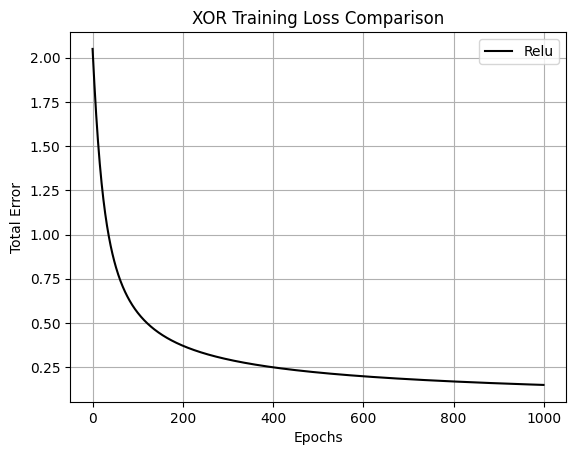

In [12]:
import matplotlib.pyplot as plt

plt.plot(errors, label='Relu', color='black')
plt.xlabel("Epochs")
plt.ylabel("Total Error")
plt.title("XOR Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()